In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

import openquantum_sde
from openquantum_sde.integrators import EulerMaruyama, Milstein, stochasticHeun
from openquantum_sde.integrators import splittingExactEuler, splittingExactMidpointEuler, splittingExactIterativeCN
from openquantum_sde.integrators import splittingExactMilstein, splittingExactHeun, splittingRK4EM, splittingRK4Milstein
from openquantum_sde.systems import TransmonCavity
from openquantum_sde.simulation import simulate_fixed_dt, simulate_adaptive_dt
from openquantum_sde.utils import calculate_num_photons

### Sanity check 1

In [11]:
# Parameters and initial conditions
maxAt_1 = 0
maxPh_1 = 50 
k_1, Omega_1, epsilon_1, U_1 = 1.0, 0.0, 5.0, 0.0
X0 = np.zeros([maxAt_1+1,maxPh_1+1], dtype=np.complex128)
X0[0,0] = 1.0

# Define system
M, N = X0.shape
trans_cavity_system_1 = TransmonCavity(M, N, k_1, Omega_1, epsilon_1, U_1)

# Define integrator
#myIntegrator1 = EulerMaruyama()
#myIntegrator1 = Milstein()
#myIntegrator1 = stochasticHeun()
#myIntegrator1 = splittingExactEuler() #taming = True
#myIntegrator1 = splittingExactMidpointEuler() #taming = True
myIntegrator1 = splittingExactIterativeCN()
#myIntegrator1 = splittingExactMilstein() #taming = True
#myIntegrator1 = splittingExactHeun() #taming = True
#myIntegrator1 = splittingRK4EM(M,N)
#myIntegrator1 = splittingRK4Milstein(M,N)

start = time.perf_counter()
dt_array_1, times_1, traj_1, traj_current_1 = simulate_adaptive_dt(
    X0 = X0, 
    nsteps_max = 30000, #300000, 
    dt_min = 1e-6, #0.0005/10.0,
    dt_max = 0.005, #0.0005*10.0,
    tol = 0.5,
    save_every = 1,
    renormalize_every = 100,
    calculate_current = True,
    integrator = myIntegrator1,
    system = trans_cavity_system_1)
end = time.perf_counter()
print(f"Time taken: {end - start:.6f} seconds")

# Calculate expected value of photons
num_photons = np.zeros(len(times_1))
for i in range(len(times_1)):
    num_photons[i] = calculate_num_photons(traj_1[i]).real

Simulating:   0%|          | 0/30000 [00:00<?, ?it/s]

Simulating: 100%|██████████| 30000/30000 [00:01<00:00, 29270.82it/s]

Time taken: 1.027360 seconds


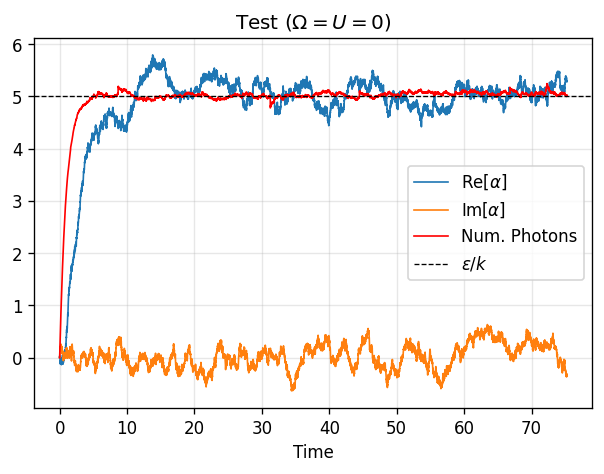

In [12]:
fig1, ax1 = plt.subplots(figsize=(6, 4), dpi=120)
ax1.plot(times_1, traj_current_1.real, label=r'Re[$\alpha$]', lw=1)
ax1.plot(times_1, traj_current_1.imag, label=r'Im[$\alpha$]', lw=1)
ax1.plot(times_1, np.sqrt(num_photons), color = 'red', label=r'Num. Photons', lw=1)
ax1.axhline(epsilon_1/k_1, color='k', ls='--', lw=0.8, label=r'$\epsilon/k$')
ax1.set_title(r'Test ($\Omega=U=0$)')
ax1.set_xlabel('Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

In [ ]:
print(times_1[-1], max(dt_array_1), min(dt_array_1))
print(dt_array_1[0:100])

75.12142974499129 0.005000000000002558 9.999999974752427e-07
[1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06
 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06
 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06
 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06
 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06
 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06
 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06
 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06
 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06
 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06 1.e-06]


### Sanity check 2

In [ ]:
# Parameters and initial conditions
maxAt_2 = 50
maxPh_2 = 50
k_2, Omega_2, epsilon_2, U_2 = 1.0, 10.0, 4.0, 0.0
X0 = np.zeros([maxAt_2+1,maxPh_2+1], dtype=np.complex128)
X0[0,0] = 1.0

# Define system
M, N = X0.shape
trans_cavity_system_2 = TransmonCavity(M, N, k_2, Omega_2, epsilon_2, U_2)

# Define integrator
#myIntegrator2 = EulerMaruyama()
#myIntegrator2 = Milstein()
#myIntegrator2 = stochasticHeun()
#myIntegrator2 = splittingExactEuler() #taming = True
#myIntegrator2 = splittingExactMidpointEuler() #taming = True
myIntegrator2 = splittingExactIterativeCN()
#myIntegrator2 = splittingExactMilstein() #taming = True
#myIntegrator2 = splittingExactHeun() #taming = True
#myIntegrator2 = splittingRK4EM(M,N)
#myIntegrator2 = splittingRK4Milstein(M,N)


start = time.perf_counter()
dt_array_2, times_2, traj_2, traj_current_2 = simulate_adaptive_dt(
    X0 = X0, 
    nsteps_max = 30000, #300000, 
    dt_min = 1e-6, #0.0005/10.0,
    dt_max = 0.005, #0.0005*10.0,
    tol = 0.5,
    save_every = 1,
    renormalize_every = 1,
    calculate_current = True,
    integrator = myIntegrator2,
    system = trans_cavity_system_2)
end = time.perf_counter()
print(f"Time taken: {end - start:.6f} seconds")

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
ax.plot(times_2, traj_current_2.real, label=r'Re[$\alpha$]', lw=1)
ax.plot(times_2, traj_current_2.imag, label=r'Im[$\alpha$]', lw=1)
ssvalue = (epsilon_2**2 / (k_2**2 + Omega_2**2/4))**(1/2)
ax.axhline(ssvalue, color='k', ls='--', lw=0.8, label=r'$\left(\frac{\epsilon^2}{k^2+\Omega^2/4}\right)^{1/2}$')
ax.set_title(r'Test ($U=0$)')
ax.set_xlabel('Time')
ax.legend()
ax.grid(True, alpha=0.3)

In [ ]:
print(times_2[-1], max(dt_array_2), min(dt_array_2))
print(dt_array_2[0:100])

### Sanity check 3

In [ ]:
# Parameters and initial conditions
maxAt_3 = 2
maxPh_3 = 2
k_3, Omega_3, epsilon_3, U_3 = 0.0, 1.0, 0.0, 0.0
X0 = np.zeros([maxAt_3+1,maxPh_3+1], dtype=np.complex128)
X0[2,0] = 1.0 

# Define system
M, N = X0.shape
trans_cavity_system_3 = TransmonCavity(M, N, k_3, Omega_3, epsilon_3, U_3)

# Define integrator
#myIntegrator3 = EulerMaruyama()
#myIntegrator3 = Milstein()
#myIntegrator3 = stochasticHeun()
#myIntegrator3 = splittingExactEuler() #taming = True
#myIntegrator3 = splittingExactMidpointEuler() #taming = True
myIntegrator3 = splittingExactIterativeCN()
#myIntegrator3 = splittingExactMilstein() #taming = True
#myIntegrator3 = splittingExactHeun() #taming = True
#myIntegrator3 = splittingRK4EM(M,N)
#myIntegrator3 = splittingRK4Milstein(M,N)


start = time.perf_counter()
dt_array_3, times_3, traj_3, traj_current_3 = simulate_adaptive_dt(
    X0 = X0, 
    nsteps_max = 1000, 
    dt_min = 1e-6, #0.0005/10.0,
    dt_max = 0.05, #0.0005*10.0,
    tol = 0.5,
    save_every = 1,
    renormalize_every = 100, 
    calculate_current = True,
    integrator = myIntegrator3,
    system = trans_cavity_system_3)
end = time.perf_counter()
print(f"Time taken: {end - start:.6f} seconds")

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
ax.plot(times_3, traj_3[:,2,0].real )
ax.plot(times_3, traj_3[:,0,2].real )
ax.plot(times_3, traj_3[:,1,1].real)
ax.set_title(r'Test ($k=\epsilon =U=0$)')
ax.set_xlabel('Time')
ax.grid(True, alpha=0.3)

In [ ]:
print(times_3[-1], max(dt_array_3), min(dt_array_3))
print(dt_array_3[0:100])